# Stratified Sampling

In this notebook, I implement the stratified sampling method for option pricing.
The content of this notebook is based on Chapter 4 of the book "Monte Carlo Methods in Financial Engineering" by Paul Glasserman.

The aim of this code is to construct strata based on the terminal values of the Wiener process and to use stratified sampling techniques to reduce the variance in an option pricing problem.

The stochastic model used for the stock price is geometric Brownian motion (GBM). Therefore, its solution has an explicit form, and there is no need to use the Euler approximation scheme to simulate its values.
However, to make this code applicable to option pricing problems that use more general stock price models, we use the Euler scheme to simulate stock price paths.

In [1]:
import numpy as np
import math
import matplotlib.pyplot as plt
from scipy.stats import norm

# 1. Parameters

In [2]:
terminal_time = 1
num_steps = 252 * terminal_time
time_step = 1/252
time_grid = np.arange(0, terminal_time + time_step, time_step)

strata_info = [
    [(0, 0.5), 30],
    [(0.5, 0.6),50],
    [(0.6, 0.7),50],
    [(0.7, 0.8),50],
    [(0.8, 0.9),50],
    [(0.9, 1.0),50]
]

riskless = 0.03

# "sigma" is a volatility term of GBM
sigma = 0.2

# "alpha" is a significance level for the confidence interval.
alpha = 0.05

intervals = [x[0] for x in strata_info]
num_samples_stratum = [x[1] for x in strata_info]
num_strata = len(strata_info)
num_total_samples = np.sum(num_samples_stratum)

# 2. Sampling from uniform distribution

The first 30 elements of "Unif" are sampled from Unif(0,0.5), the next 50 elements are sampled from Unif(0.5,0.6), and so on.

In [3]:
Unif = np.zeros(num_total_samples)

for i, (low, high) in enumerate(intervals):
    start_idx = int(np.sum(num_samples_stratum[0:i]))
    end_idx = start_idx + num_samples_stratum[i]
    Unif[start_idx:end_idx] = np.random.uniform(low, high, size=num_samples_stratum[i])

# 3. Sampling from normal distribution

We use the inverse transform method to sample from a normal distribution with its values restricted to a given range.

In [4]:
Normal = np.zeros(num_total_samples)
W = np.zeros((num_total_samples, num_steps+1))

for i in range(num_total_samples):
    Normal[i] = norm.ppf(Unif[i], loc=0, scale=1)
    W[i][num_steps] = math.sqrt(terminal_time) * Normal[i]

We use Brownian bridge construction techinique to obtain the path of Wiener processes.

In [5]:
for i in range(num_total_samples):
    for j in range(1,num_steps):
        Z = np.random.normal(loc=0, scale=1)
        W[i][j] = ((time_grid[num_steps]-time_grid[j])/(time_grid[num_steps]-time_grid[j-1])) * W[i][j-1] \
            + ((time_grid[j]-time_grid[j-1])/(time_grid[num_steps]-time_grid[j-1])) * W[i][num_steps] \
                + math.sqrt(((time_grid[num_steps]-time_grid[j])*(time_grid[j]-time_grid[j-1]))/(time_grid[num_steps]-time_grid[j-1])) * Z

# 4. Simulation of the stock price

The model for stock price is 1-dimensional GBM;
$$ \frac{dS(t)}{S(t)} = r dt + \sigma dW(t).$$
To draw its path, we use the Euler approximation method.

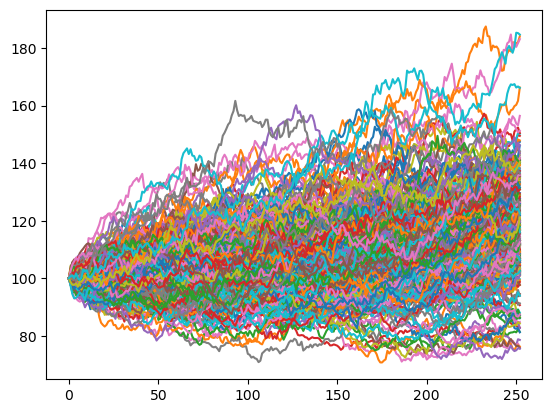

In [6]:
Stock = np.zeros((num_total_samples, num_steps+1))
for i in range(num_total_samples):
    Stock[i][0] = 100
    for j in range(1,num_steps+1):
        Stock[i][j] = Stock[i][j-1] + riskless * Stock[i][j-1] * (time_grid[j] - time_grid[j-1]) \
                        + sigma * Stock[i][j-1] * (W[i][j] - W[i][j-1])

for i in range(len(Stock)):
    plt.plot(Stock[i],)
plt.show()

# 5. Calculation of the price of call options

The value of the call option we consider is
$$e^{-rT}\mathbb{E}[(S(T) - K)^+],$$
where r is the risk-free rate, T is the terminal time and K is the strike price.

In [7]:
call_value = np.zeros(num_total_samples)
strike_price = 100

for i in range(num_total_samples):
    call_value[i] = np.exp(- riskless * terminal_time) * max(0,Stock[i][num_steps] - strike_price)

# 6. Calculation of the estimated value and confidence interval

## The estimator of stratified sampling
$n$: the total value <br>
$n_i$: the number of samples from $i$-th strata <br>
$K$: the number of strata <br>
$X$: the random variable used for constructing stratum <br>
$Y$: the target variable <br>
$p_i = P(X \in A_i)$ <br>
$q_i = n_i/n$ <br>
$\hat{Y}$: the estimator of $\mathbb{E}[Y]$<br>
Then, 
$$\hat{Y} = \sum_{i=1}^{K} p_i \frac{1}{n_i}\sum_{j=1}^{n_i}Y_{ij}.$$
Its confidence interval is
$$\hat{Y} \pm z_{\alpha/2} \frac{s(q)}{\sqrt{n}},$$
where
$$s(q) = \sqrt{\sum_{i=1}^{K} \frac{p^2_i}{q_i}s^2_i},$$
and $s^2_i$ is the sample variance of $Y_{i1}, \cdots, Y_{i n_i}$

In [8]:
p = np.array([end - start for start, end in intervals])
q = np.array(num_samples_stratum) / num_total_samples

mean = np.zeros(num_strata)
var = np.zeros(num_strata)

for i in range(num_strata):
    start_idx = int(np.sum(np.array(num_samples_stratum[0:i])))
    end_idx = start_idx + num_samples_stratum[i]
    mean[i] = np.mean(call_value[start_idx:end_idx])
    var[i] = np.var(call_value[start_idx:end_idx], ddof=1)

estimated_price = np.dot(p, mean)
total_var = np.dot(p*p/q, var)

z = norm.ppf(1 - alpha/2)
conf_int_lower = estimated_price - z * np.sqrt(total_var/num_total_samples)
conf_int_upper = estimated_price + z * np.sqrt(total_var/num_total_samples)
print(f"The estimated value is {estimated_price:.3f}, and \n\
{(1-alpha)*100}% confidence interval is ({conf_int_lower:.3f},{conf_int_upper:.3f}). \n\
The length of this interval  is {conf_int_upper - conf_int_lower:.4f}")

The estimated value is 9.318, and 
95.0% confidence interval is (8.945,9.691). 
The length of this interval  is 0.7459


# 7. Comparison of the estimated values

In [9]:
num_total_samples_2 = num_total_samples 

W_2 = np.zeros((num_total_samples_2, num_steps+1))

for i in range(num_total_samples_2):
    for j in range(1,num_steps+1):
        Z = np.random.normal(loc=0, scale=1)
        W_2[i][j] = W_2[i][j-1] + np.sqrt(time_grid[j] - time_grid[j-1]) * Z

S_2 = np.zeros((num_total_samples_2, num_steps+1))
for i in range(num_total_samples_2):
    S_2[i][0] = 100
    for j in range(1,num_steps+1):
        S_2[i][j] = S_2[i][0] * np.exp((riskless - 1/2 * (sigma) * (sigma)) * time_grid[j] + sigma * W_2[i][j])
          
call_2 = np.zeros(num_total_samples_2)

for i in range(num_total_samples_2):
    if(S_2[i][num_steps] > strike_price):
        call_2[i] = S_2[i][num_steps] - strike_price
    else:
        call_2[i] = 0

standard_deviation_call_2 = np.std(call_2, ddof=1)
standard_deviation_call_2

estimator_2 = (1/num_total_samples_2) * sum(call_2)
estimator_2

conf_int_lower_2 = estimator_2 - z * standard_deviation_call_2 / np.sqrt(num_total_samples_2)
conf_int_upper_2 = estimator_2 + z * standard_deviation_call_2 / np.sqrt(num_total_samples_2)
print(f"The estimated value is {estimator_2:.3f}, and \n\
{(1-alpha)*100}% confidence interval is ({conf_int_lower_2:.3f},{conf_int_upper_2:.3f}). \n\
The length of this interval is {conf_int_upper_2 - conf_int_lower_2:.4f}")

The estimated value is 9.987, and 
95.0% confidence interval is (8.354,11.620). 
The length of this interval is 3.2653


# References

1. Glasserman, P. (2003) *Monte Carlo Methods in Financial Engineering*. Springer, New York.